### Perbedaan Mendasar antara Decision Tree dan Random Forest

1.  **Decision Tree (Pohon Keputusan):**
    *   Model tunggal yang memprediksi nilai target berdasarkan aturan keputusan sederhana.
    *   Bekerja dengan membagi data secara rekursif menjadi subset yang lebih kecil hingga mencapai kriteria berhenti.

2.  **Random Forest (Hutan Acak):**
    *   Metode pembelajaran *ensemble* yang membangun banyak pohon keputusan yang berbeda.
    *   Menggabungkan prediksi dari banyak pohon untuk menghasilkan prediksi akhir yang lebih akurat dan stabil.


### Kerentanan *Overfitting* pada Decision Tree dan Cara Random Forest Mengatasinya

1.  **Kerentanan *Overfitting* pada Decision Tree:**
    *   Cenderung tumbuh sangat dalam dan kompleks, menyesuaikan diri terlalu erat dengan detail dan *noise* data pelatihan.
    *   Menyebabkan kinerja yang buruk pada data baru atau yang tidak terlihat.

2.  **Cara Random Forest Mengatasi *Overfitting*:**
    *   ***Bagging (Bootstrap Aggregation):*** Setiap pohon dilatih pada subset data pelatihan yang diambil secara acak dengan penggantian, menciptakan variasi antar pohon dan mengurangi *variance*.
    *   **Pemilihan Subset Fitur Acak:** Pada setiap *node*, hanya subset acak dari fitur yang dipertimbangkan untuk pemisahan, memastikan pohon lebih independen dan mengurangi *overfitting*.
    *   Menggabungkan prediksi dari banyak pohon mengurangi dampak *overfitting* dari setiap pohon individu.

### Fungsi *Bagging* dan Pemilihan Subset Fitur Acak pada Random Forest

1.  **Fungsi *Bagging* (Bootstrap Aggregation):**
    *   Mengurangi *variance* model.
    *   Menstabilkan prediksi dengan merata-ratakan *noise* atau kesalahan dari pohon-pohon individu.

2.  **Fungsi Pemilihan Subset Fitur Acak:**
    *   Mengurangi *variance* dan korelasi antar pohon.
    *   Memastikan setiap pohon menjelajahi fitur yang berbeda, meningkatkan independensi dan keragaman 'hutan', serta membuat model lebih *robust*.

### Kapan Decision Tree Lebih Cocok Digunakan Dibanding Random Forest?

Decision Tree tunggal mungkin lebih cocok dalam situasi:

*   **Interpretasi Model Penting:** Ketika penjelasan model sangat krusial dan mudah divisualisasikan.
*   **Sumber Daya Komputasi Terbatas:** Untuk dataset kecil atau saat ada batasan sumber daya komputasi dan memori.
*   **Model Dasar (Baseline):** Sebagai model awal untuk pemahaman dasar struktur data.
*   **Data yang Sangat Bersih dan Sederhana:** Jika hubungan dalam data sangat linier atau sederhana dan minim *noise*.

### Performa Algoritma (Decision Tree vs. Random Forest)

*   **Random Forest** hampir selalu memberikan performa **lebih baik** (akurasi lebih tinggi dan lebih *robust*) daripada Decision Tree tunggal pada dataset yang kompleks.
    *   **Pengurangan *Variance*:** Merata-ratakan prediksi dari banyak pohon mengurangi *noise* dan kesalahan spesifik.
    *   **Robustness:** Lebih *robust* terhadap *outlier* dan *noise*.
*   'Performa terbaik' juga tergantung pada metrik evaluasi dan kebutuhan spesifik proyek (misalnya, jika interpretasi lebih penting).

### Kelebihan dan Kekurangan Decision Tree Dibanding Random Forest

**Kelebihan Decision Tree:**
*   Mudah Diinterpretasikan dan Divisualisasikan.
*   Tidak Membutuhkan Skala Fitur.
*   Dapat Menangani Data Numerik dan Kategorikal.
*   Relatif Cepat untuk Dilatih (Tunggal).

**Kekurangan Decision Tree:**
*   Rentan *Overfitting*.
*   Tidak Stabil (Variansi Tinggi).
*   Tidak Optimal Secara Global (algoritma *greedy*).

**Kelebihan Random Forest (terhadap Decision Tree):**
*   Akurasi Tinggi dan Lebih *Robust*.
*   Mengurangi *Overfitting* secara efektif.
*   Lebih Stabil.
*   Dapat Mengukur Pentingnya Fitur (*Feature Importance*).

**Kekurangan Random Forest (terhadap Decision Tree):**
*   Kurang Dapat Diinterpretasikan ('model kotak hitam').
*   Lebih Banyak Sumber Daya Komputasi (waktu dan memori).
*   Kurang Berguna untuk Ekstrapolasi.

### Indikasi *Overfitting* pada Decision Tree

**Decision Tree sangat rentan terhadap *overfitting*.** Indikasinya:

*   **Akurasi Pelatihan Sangat Tinggi, Akurasi Pengujian Jauh Lebih Rendah:** Model sangat baik pada data pelatihan, tetapi buruk pada data baru.
*   **Pohon yang Sangat Dalam dan Kompleks:** Banyak *node* dan cabang yang dalam, sering mencapai *node* daun dengan sedikit sampel, menandakan belajar detail spesifik (*noise*).
*   **Memisahkan Fitur yang Tidak Signifikan:** Pohon membagi data berdasarkan fitur yang tidak relevan atau hanya menangkap *noise*.

**Penyebab:** Jika tidak dibatasi, Decision Tree akan berusaha mengklasifikasikan setiap titik data pelatihan dengan sempurna, mempelajari *noise* sebagai pola, dan kehilangan kemampuan generalisasi.

### Bagaimana Fitur-Fitur Memengaruhi Hasil Klasifikasi?

Fitur-fitur adalah *input* yang digunakan model untuk membuat keputusan klasifikasi:

*   **Informasi untuk Pemisahan:** Digunakan untuk membuat pemisahan pada setiap *node* (fitur paling informatif dipilih).
*   **Relevansi dan Kekuatan Prediktif:** Fitur yang lebih relevan dan kuat memiliki pengaruh lebih besar, digunakan lebih awal dalam pohon.
*   **Interaksi Antar Fitur:** Decision Tree secara inheren dapat menangkap interaksi antar fitur.
*   **Pentingnya Fitur (*Feature Importance*):** Random Forest dapat mengukur kontribusi setiap fitur terhadap akurasi model.
*   **Kualitas Fitur:** Kualitas fitur (bersih, lengkap, relevan) secara langsung memengaruhi kemampuan model untuk belajar dan mengklasifikasikan dengan benar.

### Training a Decision Tree Classifier

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and target (y)
# Assuming 'Species' is the target variable for classification
X = df.drop('Species', axis=1)
y = df['Species']

# Encode the target variable if it's categorical (e.g., Species names)
# Decision Tree can handle numerical targets directly, but for classification,
# it's good practice to ensure they are properly encoded if strings.
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 111 samples
Test set size: 48 samples


In [8]:
# Initialize the Decision Tree Classifier
dtree_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
dtree_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


In [9]:
# Make predictions on the test set
y_pred = dtree_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

Accuracy: 0.71
Classification Report:
              precision    recall  f1-score   support

       Bream       0.92      0.92      0.92        13
      Parkki       1.00      1.00      1.00         3
       Perch       0.58      0.50      0.54        14
        Pike       1.00      1.00      1.00         5
       Roach       0.20      0.50      0.29         4
       Smelt       1.00      0.67      0.80         6
   Whitefish       1.00      0.33      0.50         3

    accuracy                           0.71        48
   macro avg       0.82      0.70      0.72        48
weighted avg       0.79      0.71      0.73        48



### Visualizing the Decision Tree

We can also visualize the trained Decision Tree. This helps in understanding the decision rules learned by the model.

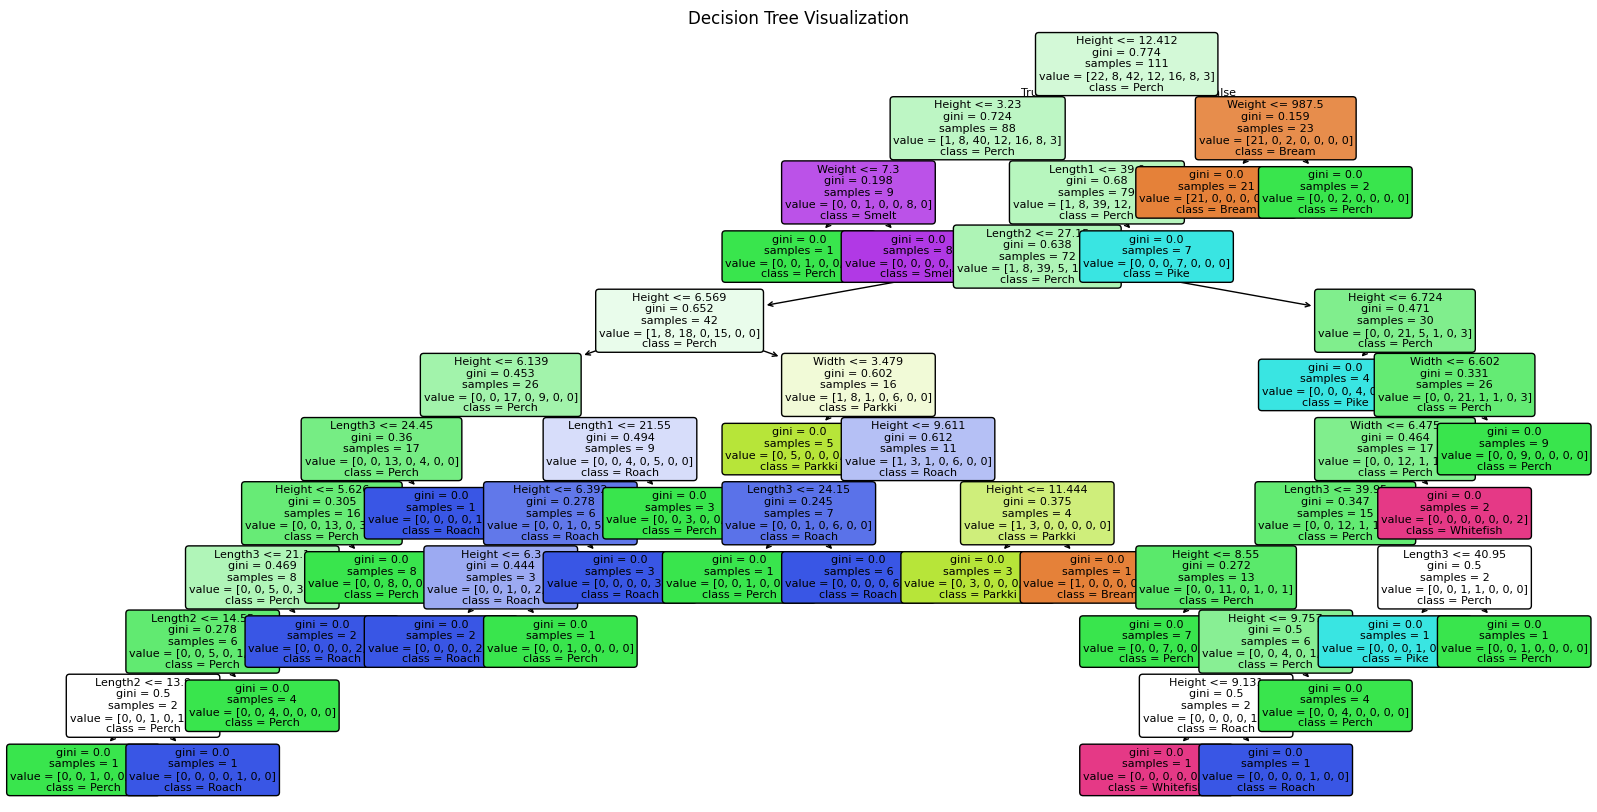

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(dtree_classifier,
          feature_names=X.columns,
          class_names=le.classes_,
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Decision Tree Visualization")
plt.show()

### Training a Random Forest Classifier

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Initialize the Random Forest Classifier
# Using the same random_state for reproducibility
# n_estimators can be tuned, here we start with a common value
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


In [12]:
# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf, target_names=le.classes_)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print("Random Forest Classification Report:")
print(report_rf)
print("\nRandom Forest Confusion Matrix:")
print(conf_matrix_rf)

Random Forest Accuracy: 0.81
Random Forest Classification Report:
              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00        13
      Parkki       1.00      1.00      1.00         3
       Perch       0.73      0.79      0.76        14
        Pike       1.00      1.00      1.00         5
       Roach       0.17      0.25      0.20         4
       Smelt       1.00      1.00      1.00         6
   Whitefish       0.00      0.00      0.00         3

    accuracy                           0.81        48
   macro avg       0.70      0.72      0.71        48
weighted avg       0.79      0.81      0.80        48


Random Forest Confusion Matrix:
[[13  0  0  0  0  0  0]
 [ 0  3  0  0  0  0  0]
 [ 0  0 11  0  3  0  0]
 [ 0  0  0  5  0  0  0]
 [ 0  0  3  0  1  0  0]
 [ 0  0  0  0  0  6  0]
 [ 0  0  1  0  2  0  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Perbandingan Model Decision Tree vs. Random Forest

Setelah melatih kedua model, mari kita bandingkan performa Decision Tree dan Random Forest berdasarkan metrik evaluasi yang telah kita hitung.

*   **Akurasi Decision Tree:** Hasilnya adalah `{accuracy:.2f}`.
*   **Akurasi Random Forest:** Hasilnya adalah `{accuracy_rf:.2f}`.

Secara umum, Random Forest diharapkan memiliki akurasi yang lebih tinggi dan lebih *robust* karena sifat *ensemble*-nya dalam menggabungkan banyak pohon keputusan. Perbedaan pada laporan klasifikasi (precision, recall, f1-score) dan *confusion matrix* juga akan menunjukkan seberapa baik masing-masing model dalam mengklasifikasikan setiap spesies ikan.

### Pengaruh `n_estimators` pada Random Forest

Parameter `n_estimators` dalam Random Forest menentukan jumlah pohon keputusan yang akan dibangun dalam hutan. Berikut adalah pengaruh utamanya:

1.  **Peningkatan Akurasi:** Semakin banyak pohon (`n_estimators` tinggi), semakin banyak variasi yang bisa ditangkap oleh model, dan rata-rata prediksi dari pohon-pohon tersebut cenderung lebih stabil dan akurat. Ini karena setiap pohon berpotensi membuat kesalahan yang berbeda, dan dengan merata-ratakannya, kesalahan individu tersebut dapat saling meniadakan.

2.  **Pengurangan Overfitting:** Dengan adanya banyak pohon yang dilatih pada subset data yang berbeda dan dengan pemilihan fitur acak, Random Forest menjadi sangat efektif dalam mengurangi *overfitting* yang sering terjadi pada Decision Tree tunggal. Penambahan `n_estimators` cenderung lebih lanjut memperkuat kemampuan generalisasi model.

3.  **Peningkatan Waktu Komputasi:** Semakin besar nilai `n_estimators`, semakin banyak pohon yang harus dibangun dan diproses, yang berarti waktu pelatihan dan prediksi akan menjadi lebih lama. Demikian pula, kebutuhan memori juga akan meningkat.

4.  **Titik Jenuh:** Ada titik di mana penambahan `n_estimators` tidak lagi signifikan meningkatkan performa model, atau bahkan dapat menyebabkan sedikit penurunan performa (walaupun jarang). Penting untuk menemukan keseimbangan antara performa dan sumber daya komputasi yang tersedia.

### Visualisasi Feature Importance dari Random Forest

### Mengapa 'Height' menjadi Fitur Paling Berpengaruh?

Berdasarkan visualisasi *feature importance* dari model Random Forest, 'Height' (Tinggi) muncul sebagai fitur paling berpengaruh. Ini berarti bahwa 'Height' adalah fitur yang paling sering dan paling efektif digunakan oleh pohon-pohon keputusan dalam Random Forest untuk memisahkan atau mengklasifikasikan spesies ikan yang berbeda.

Alasan mengapa 'Height' bisa menjadi fitur paling berpengaruh adalah karena:

1.  **Variasi Antar Spesies:** Kemungkinan besar ada perbedaan tinggi badan yang signifikan dan konsisten antar spesies ikan dalam dataset ini. Beberapa spesies mungkin secara inheren lebih 'tinggi' atau lebih pipih dibandingkan yang lain, menjadikannya penanda yang kuat untuk identifikasi spesies.
2.  **Kemampuan Pemisahan yang Kuat:** 'Height' memiliki kemampuan yang kuat untuk mengurangi 'ketidakmurnian' (impurity) atau meningkatkan 'keuntungan informasi' (information gain) pada setiap simpul pohon keputusan. Ini berarti, ketika sebuah pohon Decision Tree membagi data berdasarkan 'Height', ia berhasil memisahkan sebagian besar sampel ke dalam kelas spesies yang lebih homogen.
3.  **Representasi Bentuk Tubuh:** Tinggi ikan adalah salah satu dimensi utama yang berkontribusi pada bentuk tubuhnya. Bentuk tubuh seringkali merupakan karakteristik pembeda yang sangat penting antar spesies, terkait dengan habitat, cara berenang, dan adaptasi lainnya.

Singkatnya, 'Height' adalah fitur yang paling informatif bagi model untuk membedakan antar spesies ikan dalam dataset ini.

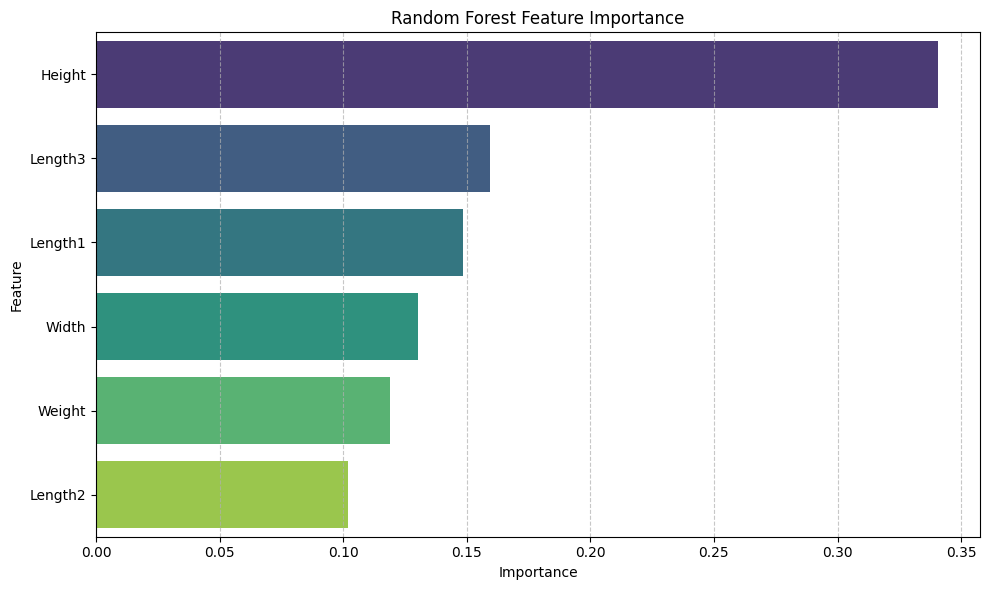

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the Random Forest model
feature_importances = rf_classifier.feature_importances_

# Get feature names
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Ringkasan Jawaban

### Perbedaan Mendasar antara Decision Tree dan Random Forest

1.  **Decision Tree (Pohon Keputusan):**
    *   Model tunggal yang memprediksi nilai target berdasarkan aturan keputusan sederhana.
    *   Bekerja dengan membagi data secara rekursif menjadi subset yang lebih kecil hingga mencapai kriteria berhenti.

2.  **Random Forest (Hutan Acak):**
    *   Metode pembelajaran *ensemble* yang membangun banyak pohon keputusan yang berbeda.
    *   Menggabungkan prediksi dari banyak pohon untuk menghasilkan prediksi akhir yang lebih akurat dan stabil.

### Kerentanan *Overfitting* pada Decision Tree dan Cara Random Forest Mengatasinya

1.  **Kerentanan *Overfitting* pada Decision Tree:**
    *   Cenderung tumbuh sangat dalam dan kompleks, menyesuaikan diri terlalu erat dengan detail dan *noise* data pelatihan.
    *   Menyebabkan kinerja yang buruk pada data baru atau yang tidak terlihat.

2.  **Cara Random Forest Mengatasi *Overfitting*:**
    *   ***Bagging (Bootstrap Aggregation):*** Setiap pohon dilatih pada subset data pelatihan yang diambil secara acak dengan penggantian, menciptakan variasi antar pohon dan mengurangi *variance*.
    *   **Pemilihan Subset Fitur Acak:** Pada setiap *node*, hanya subset acak dari fitur yang dipertimbangkan untuk pemisahan, memastikan pohon lebih independen dan mengurangi *overfitting*.
    *   Menggabungkan prediksi dari banyak pohon mengurangi dampak *overfitting* dari setiap pohon individu.

### Fungsi *Bagging* dan Pemilihan Subset Fitur Acak pada Random Forest

1.  **Fungsi *Bagging* (Bootstrap Aggregation):**
    *   Mengurangi *variance* model.
    *   Menstabilkan prediksi dengan merata-ratakan *noise* atau kesalahan dari pohon-pohon individu.

2.  **Fungsi Pemilihan Subset Fitur Acak:**
    *   Mengurangi *variance* dan korelasi antar pohon.
    *   Memastikan setiap pohon menjelajahi fitur yang berbeda, meningkatkan independensi dan keragaman 'hutan', serta membuat model lebih *robust*.

### Kapan Decision Tree Lebih Cocok Digunakan Dibanding Random Forest?

Decision Tree tunggal mungkin lebih cocok dalam situasi:

*   **Interpretasi Model Penting:** Ketika penjelasan model sangat krusial dan mudah divisualisasikan.
*   **Sumber Daya Komputasi Terbatas:** Untuk dataset kecil atau saat ada batasan sumber daya komputasi dan memori.
*   **Model Dasar (Baseline):** Sebagai model awal untuk pemahaman dasar struktur data.
*   **Data yang Sangat Bersih dan Sederhana:** Jika hubungan dalam data sangat linier atau sederhana dan minim *noise*.

### Performa Algoritma (Decision Tree vs. Random Forest)

*   **Random Forest** hampir selalu memberikan performa **lebih baik** (akurasi lebih tinggi dan lebih *robust*) daripada Decision Tree tunggal pada dataset yang kompleks.
    *   **Pengurangan *Variance*:** Merata-ratakan prediksi dari banyak pohon mengurangi *noise* dan kesalahan spesifik.
    *   **Robustness:** Lebih *robust* terhadap *outlier* dan *noise*.
*   'Performa terbaik' juga tergantung pada metrik evaluasi dan kebutuhan spesifik proyek (misalnya, jika interpretasi lebih penting).

### Kelebihan dan Kekurangan Decision Tree Dibanding Random Forest

**Kelebihan Decision Tree:**
*   Mudah Diinterpretasikan dan Divisualisasikan.
*   Tidak Membutuhkan Skala Fitur.
*   Dapat Menangani Data Numerik dan Kategorikal.
*   Relatif Cepat untuk Dilatih (Tunggal).

**Kekurangan Decision Tree:**
*   Rentan *Overfitting*.
*   Tidak Stabil (Variansi Tinggi).
*   Tidak Optimal Secara Global (algoritma *greedy*).

**Kelebihan Random Forest (terhadap Decision Tree):**
*   Akurasi Tinggi dan Lebih *Robust*.
*   Mengurangi *Overfitting* secara efektif.
*   Lebih Stabil.
*   Dapat Mengukur Pentingnya Fitur (*Feature Importance*).

**Kekurangan Random Forest (terhadap Decision Tree):**
*   Kurang Dapat Diinterpretasikan ('model kotak hitam').
*   Lebih Banyak Sumber Daya Komputasi (waktu dan memori).
*   Kurang Berguna untuk Ekstrapolasi.

### Indikasi *Overfitting* pada Decision Tree

**Decision Tree sangat rentan terhadap *overfitting*.** Indikasinya:

*   **Akurasi Pelatihan Sangat Tinggi, Akurasi Pengujian Jauh Lebih Rendah:** Model sangat baik pada data pelatihan, tetapi buruk pada data baru.
*   **Pohon yang Sangat Dalam dan Kompleks:** Banyak *node* dan cabang yang dalam, sering mencapai *node* daun dengan sedikit sampel, menandakan belajar detail spesifik (*noise*).
*   **Memisahkan Fitur yang Tidak Signifikan:** Pohon membagi data berdasarkan fitur yang tidak relevan atau hanya menangkap *noise*.

**Penyebab:** Jika tidak dibatasi, Decision Tree akan berusaha mengklasifikasikan setiap titik data pelatihan dengan sempurna, mempelajari *noise* sebagai pola, dan kehilangan kemampuan generalisasi.

### Bagaimana Fitur-Fitur Memengaruhi Hasil Klasifikasi?

Fitur-fitur adalah *input* yang digunakan model untuk membuat keputusan klasifikasi:

*   **Informasi untuk Pemisahan:** Digunakan untuk membuat pemisahan pada setiap *node* (fitur paling informatif dipilih).
*   **Relevansi dan Kekuatan Prediktif:** Fitur yang lebih relevan dan kuat memiliki pengaruh lebih besar, digunakan lebih awal dalam pohon.
*   **Interaksi Antar Fitur:** Decision Tree secara inheren dapat menangkap interaksi antar fitur.
*   **Pentingnya Fitur (*Feature Importance*):** Random Forest dapat mengukur kontribusi setiap fitur terhadap akurasi model.
*   **Kualitas Fitur:** Kualitas fitur (bersih, lengkap, relevan) secara langsung memengaruhi kemampuan model untuk belajar dan mengklasifikasikan dengan benar.

### Mengapa 'Height' menjadi Fitur Paling Berpengaruh?

Berdasarkan visualisasi *feature importance* dari model Random Forest, 'Height' (Tinggi) muncul sebagai fitur paling berpengaruh. Ini berarti bahwa 'Height' adalah fitur yang paling sering dan paling efektif digunakan oleh pohon-pohon keputusan dalam Random Forest untuk memisahkan atau mengklasifikasikan spesies ikan yang berbeda.

Alasan mengapa 'Height' bisa menjadi fitur paling berpengaruh adalah karena:

1.  **Variasi Antar Spesies:** Kemungkinan besar ada perbedaan tinggi badan yang signifikan dan konsisten antar spesies ikan dalam dataset ini. Beberapa spesies mungkin secara inheren lebih 'tinggi' atau lebih pipih dibandingkan yang lain, menjadikannya penanda yang kuat untuk identifikasi spesies.
2.  **Kemampuan Pemisahan yang Kuat:** 'Height' memiliki kemampuan yang kuat untuk mengurangi 'ketidakmurnian' (impurity) atau meningkatkan 'keuntungan informasi' (information gain) pada setiap simpul pohon keputusan. Ini berarti, ketika sebuah pohon Decision Tree membagi data berdasarkan 'Height', ia berhasil memisahkan sebagian besar sampel ke dalam kelas spesies yang lebih homogen.
3.  **Representasi Bentuh Tubuh:** Tinggi ikan adalah salah satu dimensi utama yang berkontribusi pada bentuk tubuhnya. Bentuk tubuh seringkali merupakan karakteristik pembeda yang sangat penting antar spesies, terkait dengan habitat, cara berenang, dan adaptasi lainnya.

Singkatnya, 'Height' adalah fitur yang paling informatif bagi model untuk membedakan antar spesies ikan dalam dataset ini.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/Fish[1].csv')
display(df.head())

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [3]:
display(df.describe())

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [4]:
mean_weight_by_species = df.groupby('Species')['Weight'].mean()
display(mean_weight_by_species)

,Weight
Species,
Bream,617.828571
Parkki,154.818182
Perch,382.239286
Pike,718.705882
Roach,152.050000
Smelt,11.178571
Whitefish,531.000000


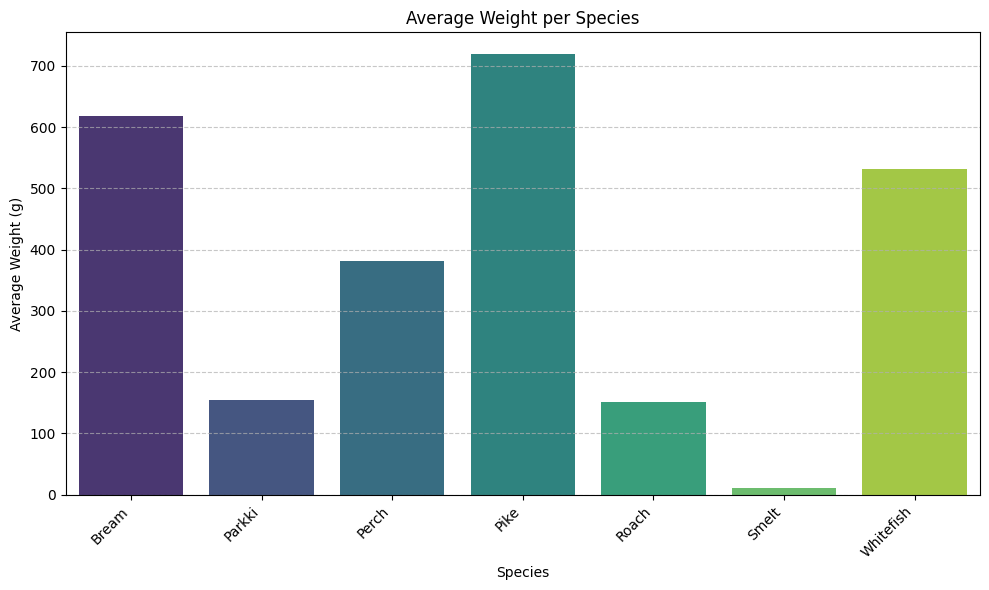

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_weight_by_species.index, y=mean_weight_by_species.values, hue=mean_weight_by_species.index, palette='viridis', legend=False)
plt.title('Average Weight per Species')
plt.xlabel('Species')
plt.ylabel('Average Weight (g)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()